### Roda GLMM para ver o impacto das combinações de features

Vamos olhar o quanto as palavras chaves impactam no processo de seleção

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import openai
import numpy as np
import time
import os
from dotenv import load_dotenv, find_dotenv
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
### style de execução
tqdm.pandas()

In [3]:
# 1. Configurar para exibir todas as linhas
pd.set_option('display.max_rows', None)

# 2. Configurar para exibir todas as colunas
pd.set_option('display.max_columns', None)

## Leitura e processamento dos resultados processados

In [4]:
# RSL1
df_rsl1 = pd.read_csv("/data/codigos/dados/resultados/resultados_empilhados_llms_slr1_prep_GLMM_v2.csv", encoding='utf-8')
df_rsl1.head()

,ID,slr,model_id,set_features,IC1,IC2,llm_IC1_0,llm_IC2_0,llm_IC1_1,llm_IC2_1,llm_IC1_2,llm_IC2_2,llm_IC1_3,llm_IC2_3,llm_IC1_4,llm_IC2_4,result_bench,result_llm_0,result_llm_1,result_llm_2,result_llm_3,result_llm_4
0,slr1_77,slr1,gpt-4o,title+abstract,7.0,6.0,6,5,6,5,6,5,6,5,6,5,1,1,1,1,1,1
1,slr1_21,slr1,gpt-4o,title+abstract,1.0,4.0,3,4,3,4,3,3,3,4,3,4,0,0,0,0,0,0
2,slr1_123,slr1,gpt-4o,title+abstract,7.0,6.0,6,3,6,3,5,3,6,3,5,3,0,0,0,0,0,0
3,slr1_71,slr1,gpt-4o,title+abstract,1.0,5.0,1,4,3,4,1,4,1,4,3,4,0,0,0,0,0,0
4,slr1_99,slr1,gpt-4o,title+abstract,7.0,7.0,6,6,6,6,6,6,6,6,6,6,1,1,1,1,1,1


In [5]:
# RSL2
df_rsl2 = pd.read_csv("/data/codigos/dados/resultados/resultados_empilhados_llms_slr2_prep_GLMM_v2.csv", encoding='utf-8')
df_rsl2.head()

,ID,slr,model_id,set_features,IC1,IC2,llm_IC1_0,llm_IC2_0,llm_IC1_1,llm_IC2_1,llm_IC1_2,llm_IC2_2,llm_IC1_3,llm_IC2_3,llm_IC1_4,llm_IC2_4,result_bench,result_llm_0,result_llm_1,result_llm_2,result_llm_3,result_llm_4
0,slr2_81,slr2,gpt-4.1,title+abstract,2,2,5,5,5,5,5,5,5,5,6,5,1,1,1,1,1,1
1,slr2_318,slr2,gpt-4.1,title+abstract,2,2,4,3,4,3,4,3,4,3,4,3,0,0,0,0,0,0
2,slr2_285,slr2,gpt-4.1,title+abstract,5,2,3,2,3,2,3,2,3,2,3,2,0,0,0,0,0,0
3,slr2_58,slr2,gpt-4.1,title+abstract,6,6,6,5,6,5,6,5,6,5,6,5,1,1,1,1,1,1
4,slr2_444,slr2,gpt-4.1,title+abstract,4,2,4,1,1,1,4,1,1,1,4,2,0,0,0,0,0,0


In [6]:
print("Shape RSL1:", df_rsl1.shape)
print("Shape RSL2:", df_rsl2.shape)

Shape RSL1: (991, 22)
Shape RSL2: (988, 22)


In [7]:
# empilhando
df_dados = pd.concat([df_rsl1, df_rsl2], ignore_index=True)
df_dados.shape

(1979, 22)

## Modelagem

In [8]:
import re
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
from statsmodels.stats.proportion import proportion_confint

In [9]:
def to_long(df):
    """
    =========================================================
    1) LONG: uma linha por execução (run)
    df: colunas mínimas -> ['ID','slr','model_id','set_features','result_bench',
                             'result_llm_0',...,'result_llm_4']
    =========================================================
    """
    run_cols = sorted([c for c in df.columns if re.fullmatch(r"result_llm_\d+", c)],
                      key=lambda x: int(re.search(r"(\d+)$", x).group(1)))
    frames = []
    for r, col in enumerate(run_cols):
        tmp = df[["ID","slr","model_id","set_features","result_bench"]].copy()
        tmp["run_id"] = r
        tmp["llm_decision"] = df[col].astype(int)
        frames.append(tmp)
    long = pd.concat(frames, ignore_index=True)
    long["y"] = (long["llm_decision"] == long["result_bench"]).astype(int)
    # ids de agrupamento p/ efeitos aleatórios
    long["pair_id"] = long["ID"].astype(str) + "|" + long["model_id"].astype(str)
    # categorias
    for c in ["ID","slr","model_id","set_features","run_id","pair_id"]:
        long[c] = long[c].astype("category")
    return long

In [10]:
df_prep = to_long(df=df_dados)

In [11]:
df_prep.head()

,ID,slr,model_id,set_features,result_bench,run_id,llm_decision,y,pair_id
0,slr1_77,slr1,gpt-4o,title+abstract,1,0,1,1,slr1_77|gpt-4o
1,slr1_21,slr1,gpt-4o,title+abstract,0,0,0,1,slr1_21|gpt-4o
2,slr1_123,slr1,gpt-4o,title+abstract,0,0,0,1,slr1_123|gpt-4o
3,slr1_71,slr1,gpt-4o,title+abstract,0,0,0,1,slr1_71|gpt-4o
4,slr1_99,slr1,gpt-4o,title+abstract,1,0,1,1,slr1_99|gpt-4o


In [12]:
print("Shape DADOS:", df_dados.shape)
print("Shape PREP:", df_prep.shape)

Shape DADOS: (1979, 22)
Shape PREP: (9895, 9)


In [13]:
df_prep["y"].value_counts(normalize=True)

y
1    0.756948
0    0.243052
Name: proportion, dtype: float64

In [ ]:
print("ref set_features:", df_prep["set_features"].cat.categories[0])
print("ref model_id   :", df_prep["model_id"].cat.categories[0])

#### Modelo

* efeito fixo: coisas que queremos mensurar, no nosso caso como as diferentes configuracoes de informacao e os modelos impactam no desfecho.
* efeito aleatorio: São fontes de variação que nao queremos mensurar mas que precisam ser adicionados seja para capturar correlacoes, separar heterogeneiddade.

In [ ]:
# efeito fixo: set de features +modelos: quanto muda a probabilidade de acerto quando troca de condicao ou de modelo?
formula = "y ~ C(set_features) * C(model_id)"

# variance componentes/efeitos aleatórios: artigo, slr, par (ID+modelo)
vc = {
    "article": "0 + C(ID)",
    "slr": "0 + C(slr)",
    "pair": "0 + C(pair_id)"
}


In [ ]:
mod = BinomialBayesMixedGLM.from_formula(formula, vc, df_prep)
res = mod.fit_vb()   # ou .fit() se quiser MCMC


In [ ]:
print(res.summary())

Aqui as referencias são "set_features = abstract" e "model_id=Llama-4-Scout-17B-16E-Instruct". Assim para o modelo base "llama" temos que o uso de title+abstract é a melhor opção. Alem disso:
* article SD = 3.57 (bem grande) os artigos variam em dificuldade.
* pair SD = 1.96 há correlaçãop forte nas 5 execuçãoes (artigoxmodelo) mas isso é esperado.
* slr SD = 0.205 diferença média pequena entre as SLRs após controlar os fixos.

#### Probabilidades marginais (EMMs-like) e ICs

In [ ]:
df_fit = df_prep.copy()  # ou df_prep
df_fit = df_fit.sort_index()                 # garantia
df_fit["p_hat"] = res.model.predict(res.params)  # P(y=1)

# utilitário: EMMs-like a partir de p_hat já colado
def emmeans_from_phat(df_fit, group_cols):
    return (df_fit[group_cols + ["p_hat"]]
            .groupby(group_cols, observed=True)["p_hat"]
            .mean().reset_index())

emm = emmeans_from_phat(df_fit, ["model_id","set_features"])
df_emms = pd.DataFrame(emm.sort_values(["model_id","set_features"]))
print(emm.sort_values(["model_id","set_features"]))


In [ ]:
df_emms.sort_values(["p_hat"], ascending=False)

In [ ]:
df_emms.head()

In [ ]:
def deltas_vs_base(
    emm: pd.DataFrame,
    base_feature: str = "abstract",
    id_col: str = "model_id",
    feature_col: str = "set_features",
    value_col: str = "p_hat",
    drop_base: bool = False,      # se True, remove as linhas da base (Δ=0)
    round_pp: int | None = 2      # casas decimais para Δ p.p. (None = sem arredondar)
) -> pd.DataFrame:
    """
    Calcula Δ (pontos percentuais) por (modelo × feature) em relação à base `base_feature`
    dentro de cada modelo.
    """
    df = emm.copy()

    # checagens mínimas
    for c in [id_col, feature_col, value_col]:
        if c not in df.columns:
            raise ValueError(f"coluna obrigatória ausente: {c}")

    # preservar ordem original de categorias (se houver)
    feat_order = None
    if pd.api.types.is_categorical_dtype(df[feature_col]):
        feat_order = df[feature_col].cat.categories

    # base por modelo
    base = (df[df[feature_col] == base_feature][[id_col, value_col]]
              .rename(columns={value_col: "p_base"}))

    # faz o merge e calcula deltas
    out = (df.merge(base, on=id_col, how="left", indicator=True)
             .query("_merge == 'both'")            # descarta modelos sem a base
             .drop(columns="_merge"))

    out["delta"]    = out[value_col] - out["p_base"]
    out["delta_pp"] = 100 * out["delta"]

    # ordenação amigável
    if feat_order is not None:
        out[feature_col] = out[feature_col].astype(
            pd.CategoricalDtype(categories=feat_order, ordered=True)
        )
    out = out.sort_values([id_col, feature_col])

    # arredondamento opcional
    if round_pp is not None:
        out["delta_pp"] = out["delta_pp"].round(round_pp)

    # remover a linha da base, se desejado
    if drop_base:
        out = out[out[feature_col] != base_feature]

    # colunas finais mais úteis
    cols = [id_col, feature_col, value_col, "p_base", "delta_pp"]
    return out[cols]


In [ ]:
df_deltas = deltas_vs_base(emm=df_emms, base_feature="abstract", drop_base=False)
df_deltas

**title+keywords** é consistentemente pior na maioria dos modelos (forte queda em Gemini-2.5, GPT-4o, GPT-4.1, Llama).

**abstract+keywords** é neutro/levemente positivo para GPT-4.1/4o e negativo para Llama/Haiku; varia por família.

**title+abstract** ajuda Llama, Haiku, Gemini-1.5, mas piora em GPT-4o e ligeiramente em Sonnet.

**title+abstract+keywords** muitas vezes é neutro ou pior, com exceção de Sonnet (melhor leve); Llama sofre queda grande aqui.

Níveis de 𝑝 são em geral altos (>0.9) — reforça a importância de reportar Δ p.p. com IC95% para separar diferenças pequenas de ruído.

#### Bootstrap

In [14]:

def to_long_with_accuracy(df_wide: pd.DataFrame) -> pd.DataFrame:
    """
    df_wide: colunas mínimas -> ['ID','slr','model_id','set_features','result_bench',
                                 'result_llm_0',...,'result_llm_4']
    Retorna LONG: uma linha por (artigo × modelo × set × run) com y = 1{llm == bench}.
    """
    # detectar colunas de runs
    run_cols = sorted([c for c in df_wide.columns if re.fullmatch(r"result_llm_\d+", c)],
                      key=lambda x: int(re.search(r"(\d+)$", x).group(1)))
    if not run_cols:
        raise ValueError("Não encontrei colunas result_llm_* no dataframe.")

    long = []
    for r, col in enumerate(run_cols):
        tmp = df_wide[["ID","slr","model_id","set_features","result_bench"]].copy()
        tmp["run_id"] = r
        # garantir binário
        tmp["llm_decision"] = df_wide[col].astype(int)
        tmp["bench"] = df_wide["result_bench"].astype(int)
        tmp["y"] = (tmp["llm_decision"] == tmp["bench"]).astype(int)  # ACERTO vs bench
        long.append(tmp)

    dfl = pd.concat(long, ignore_index=True)
    # tipos/categorias (opcional)
    for c in ["ID","slr","model_id","set_features","run_id"]:
        dfl[c] = dfl[c].astype("category")
    return dfl

# exemplo:
# dfl = to_long_with_accuracy(df_base)  # seu DF empilhado wide


In [15]:
dfl=to_long_with_accuracy(df_wide=df_dados)

In [16]:
dfl.head(2)

,ID,slr,model_id,set_features,result_bench,run_id,llm_decision,bench,y
0,slr1_77,slr1,gpt-4o,title+abstract,1,0,1,1,1
1,slr1_21,slr1,gpt-4o,title+abstract,0,0,0,0,1


In [17]:
def accuracy_by_article(dfl: pd.DataFrame) -> pd.DataFrame:
    return (dfl.groupby(["model_id","set_features","ID","slr"], observed=True)["y"]
               .mean()
               .rename("acc")
               .reset_index())

In [18]:
def delta_takw_vs_ta_bootstrap_from_long(dfl: pd.DataFrame,
                                         base="title+abstract",
                                         plus="title+abstract+keywords",
                                         B=2000, seed=123, stratify_slr=True) -> pd.DataFrame:
    """
    Usa 'y' (acerto vs result_bench) por execução -> média por ARTIGO (pareado).
    Retorna Δ p.p. (plus - base) por model_id com IC95% (bootstrap por artigo).
    """
    rng = np.random.default_rng(seed)
    acc_art = accuracy_by_article(dfl)

    results = []
    for model in acc_art["model_id"].unique():
        sub = acc_art[acc_art["model_id"]==model]
        if not {base, plus}.issubset(set(sub["set_features"].unique())):
            results.append({"model_id": model, "delta_pp": np.nan, "ci_low_pp": np.nan, "ci_high_pp": np.nan})
            continue

        # pivot por artigo para alinhar TA e TA+KW no MESMO artigo (pareado)
        wide = (sub[sub["set_features"].isin([base, plus])]
                  .pivot_table(index="ID", columns="set_features", values="acc"))
        wide = wide.dropna()
        if wide.empty:
            results.append({"model_id": model, "delta_pp": np.nan, "ci_low_pp": np.nan, "ci_high_pp": np.nan})
            continue

        # ponto (diferença das médias por ARTIGO)
        delta_point = (wide[plus].mean() - wide[base].mean())

        # bootstrap por ARTIGO (opcionalmente estratificado por SLR)
        stats = []
        if stratify_slr:
            # mapeia artigo -> slr
            id_slr = (sub[["ID","slr"]].drop_duplicates()
                                    .set_index("ID")["slr"].astype(str).to_dict())
            slr_of_id = wide.index.to_series().map(id_slr)
            ids_by_slr = {s: wide.index[slr_of_id==s].values for s in slr_of_id.unique()}
            for _ in range(B):
                sampled_ids = np.concatenate([
                    rng.choice(ids, size=len(ids), replace=True) for s, ids in ids_by_slr.items() if len(ids)>0
                ])
                wb = wide.loc[sampled_ids]
                stats.append((wb[plus].mean() - wb[base].mean()))
        else:
            ids = wide.index.values
            for _ in range(B):
                take = rng.choice(ids, size=len(ids), replace=True)
                wb = wide.loc[take]
                stats.append((wb[plus].mean() - wb[base].mean()))

        lo, hi = np.percentile(stats, [2.5, 97.5])
        results.append({
            "model_id": model,
            "delta_pp": 100*delta_point,
            "ci_low_pp": 100*lo,
            "ci_high_pp": 100*hi
        })

    return pd.DataFrame(results).sort_values("model_id")

# Exemplo de uso:
# dfl = to_long_with_accuracy(df_base)
# df_contr_simple = delta_takw_vs_ta_bootstrap_from_long(dfl, B=2000, seed=42, stratify_slr=True)
# print(df_contr_simple)


In [19]:
from math import sqrt

def meta_random_from_ci(df, delta_col="delta_pp", lo_col="ci_low_pp", hi_col="ci_high_pp"):
    """
    df: uma linha por modelo com Δ p.p. e IC95% (percentil bootstrap).
    Retorna FE pooled, RE pooled (DL), I2 e intervalo de predição.
    -Se RE_delta > 0 e o IC95% RE não cobre 0 ⇒ em média, TA é melhor que A.

    -I² alto sugere que o efeito varia muito entre modelos (o que faz sentido).

    -O intervalo de predição te diz quanto esperar em um modelo novo.
    """
    d  = df[delta_col].values.astype(float)
    lo = df[lo_col].values.astype(float)
    hi = df[hi_col].values.astype(float)
    k = len(d)

    # SE aproximado a partir do IC95% (normal approx.)
    se = (hi - lo) / (2*1.96)
    vi = se**2

    # ---- FIXED EFFECT
    w_FE = 1/vi
    d_FE = np.sum(w_FE * d) / np.sum(w_FE)
    se_FE = sqrt(1/np.sum(w_FE))
    ci_FE = (d_FE - 1.96*se_FE, d_FE + 1.96*se_FE)

    # ---- RANDOM EFFECTS (DerSimonian-Laird)
    w = w_FE
    d_bar = d_FE
    Q = np.sum(w*(d - d_bar)**2)
    df_Q = k - 1
    C = np.sum(w) - np.sum(w**2)/np.sum(w)
    tau2 = max(0.0, (Q - df_Q)/C) if k > 1 else 0.0

    w_RE = 1/(vi + tau2)
    d_RE = np.sum(w_RE * d) / np.sum(w_RE)
    se_RE = sqrt(1/np.sum(w_RE))
    ci_RE = (d_RE - 1.96*se_RE, d_RE + 1.96*se_RE)

    # I^2 (% heterogeneidade)
    I2 = max(0.0, (Q - df_Q)/Q)*100 if k > 1 and Q>0 else 0.0

    # Intervalo de predição (para um novo modelo)
    pred_se = sqrt(tau2 + se_RE**2)
    pi_RE = (d_RE - 1.96*sqrt(tau2 + 1/np.sum(w_RE)),
             d_RE + 1.96*sqrt(tau2 + 1/np.sum(w_RE)))

    return pd.DataFrame([{
        "k": k,
        "FE_delta": d_FE, "FE_ci_low": ci_FE[0], "FE_ci_high": ci_FE[1],
        "RE_delta": d_RE, "RE_ci_low": ci_RE[0], "RE_ci_high": ci_RE[1],
        "tau2": tau2, "I2_pct": I2,
        "pred_low": pi_RE[0], "pred_high": pi_RE[1]
    }])



In [47]:



def plot_delta_pp_ci(df,
                     model_col="model_id",
                     delta_col="delta_pp",
                     lo_col="ci_low_pp",
                     hi_col="ci_high_pp",
                     title="Percentage gains in accuracy when adding keywords",
                     axlabel="Percentage point difference",
                     aylabel="LLM model",
                     figsize=None,
                     xsize=[-27,25],
                     savepath=None):
    """
    df: DataFrame com colunas [model_id, delta_pp, ci_low_pp, ci_high_pp]
    """
    d = df[[model_col, delta_col, lo_col, hi_col]].copy()
    d = d.dropna(subset=[delta_col, lo_col, hi_col])
    # ordena por efeito
    d = d.sort_values(delta_col).reset_index(drop=True)

    # erros para o errorbar (distância do ponto aos limites)
    err_low  = d[delta_col] - d[lo_col]
    err_high = d[hi_col] - d[delta_col]
    err = np.vstack([err_low.to_numpy(), err_high.to_numpy()])

    # cores: verde (positivo), vermelho (negativo), cinza próximo de zero
    def color_map(x):
        if x > 0.5:   return "#1f77b4"  # verde
        if x < -0.5:  return "#d62728"  # vermelho
        return "#7f7f7f"                # cinza
    colors = d[delta_col].apply(color_map).tolist()

    n = len(d)
    if figsize is None:
        figsize = (9, max(3, 0.45*n))

    sns.set_theme(style="whitegrid",)
    fig, ax = plt.subplots(figsize=figsize)

    # barras horizontais
    ax.barh(d[model_col], d[delta_col], color=colors, alpha=0.9)

    # barras de erro (IC95%)
    ax.errorbar(x=d[delta_col], y=np.arange(n),
                xerr=err, fmt="none", ecolor="black",
                elinewidth=1.5, capsize=4, )
    
    ax.tick_params(axis='both', labelsize=16)
    
    # linha vertical em 0 (referência)
    ax.axvline(0, color="black", linewidth=1.2, linestyle="--")

    # anotações nos extremos das barras
    for i, (y, x, lo, hi) in enumerate(zip(d[model_col], d[delta_col], d[lo_col], d[hi_col])):
        txt = f"{x:.2f} p.p. [{lo:.2f}, {hi:.2f}]"
        # posição do texto: à direita se positivo, à esquerda se negativo
        if x >= 0:
            ax.text(x + 0.6, i+0.2, txt, va="center", ha="left", fontsize=12)
        else:
            ax.text(x - 0.6, i+0.2, txt, va="center", ha="right", fontsize=12)

    ax.set_xlabel(axlabel,fontsize=16)
    ax.set_ylabel(aylabel,fontsize=16)
    ax.set_title(title, pad=12,fontsize=18,loc='center')
    # ax.text(-0.15, 1.08, title,
    #     transform=ax.transAxes,
    #     fontsize=18,
    #     va='top',
    #     ha='left')
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    ax.grid(axis="x", linestyle=":", alpha=0.5)
    ax.set_xlim(xsize)
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
    return fig, ax


In [21]:
# dataframe para guardar as comparacoes
df_meta_ic =pd.DataFrame()

#### abstract vc abstrct+keywords

In [22]:
df_contr_simple2 = delta_takw_vs_ta_bootstrap_from_long(dfl, 
                                                       base="abstract",
                                                       plus="abstract+keywords",
                                                       B=2000, seed=42, stratify_slr=True)

/tmp/ipykernel_82028/3656458791.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="ID", columns="set_features", values="acc"))
/tmp/ipykernel_82028/3656458791.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="ID", columns="set_features", values="acc"))
/tmp/ipykernel_82028/3656458791.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="ID", columns="set_features", values="acc"))
/tmp/ipykernel_82028/3656458791.py:21: FutureWarning: The def

In [23]:
df_contr_simple2

,model_id,delta_pp,ci_low_pp,ci_high_pp
0,Llama-4-Scout-17B-16E-Instruct,-1.0,-7.00,4.00
1,claude-3-5-haiku-20241022,-6.0,-15.20,2.01
2,claude-3-5-sonnet-20241022,0.8,-3.20,4.80
3,gemini-1.5-flash,-1.2,-5.60,2.00
4,gemini-2.5-flash,-0.8,-4.01,2.40
5,gpt-4.1,2.0,0.00,4.80
6,gpt-4o,0.4,-5.20,6.00


(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Percent-Point Gain in Accuracy - Baseline: \n Abstract vs. Plus: Abstract + Keywords'}, xlabel='Percentage point difference', ylabel='LLM model'>)

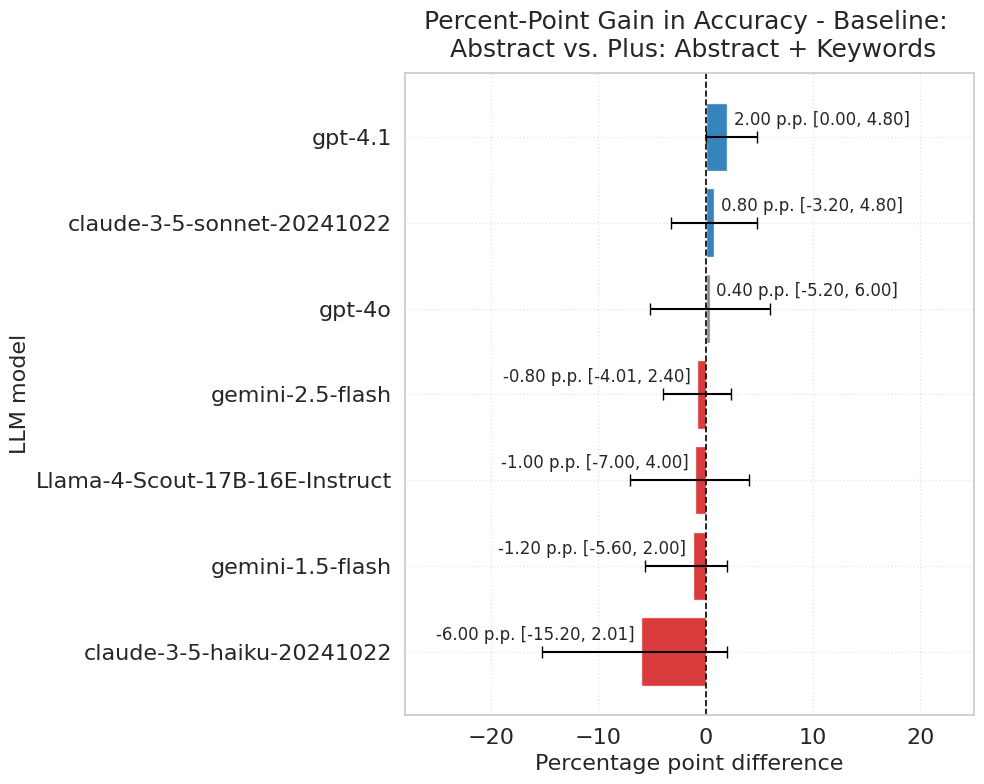

In [48]:
plot_delta_pp_ci(df = df_contr_simple2,
                     model_col="model_id",
                     delta_col="delta_pp",
                     lo_col="ci_low_pp",
                     hi_col="ci_high_pp",
                    title="Percent-Point Gain in Accuracy - Baseline: \n Abstract vs. Plus: Abstract + Keywords",
                     axlabel="Percentage point difference",
                     aylabel="LLM model",
                     figsize=(10,8),
                     xsize=[-28,25],
                     savepath='/data/codigos/dados/resultados/figuras/slr1_2_fase_2_baseline1.png')



In [49]:
df_1 = meta_random_from_ci(df = df_contr_simple2, delta_col="delta_pp", lo_col="ci_low_pp", hi_col="ci_high_pp")
df_1["baseline"] = "abstract"
df_1["contrast"] = "abstract+keywords"


# guarda
df_meta_ic = pd.concat([df_meta_ic,df_1],ignore_index=True)
df_meta_ic

,k,FE_delta,FE_ci_low,FE_ci_high,RE_delta,RE_ci_low,RE_ci_high,tau2,I2_pct,pred_low,pred_high,baseline,contrast
0,7,0.280371,-1.161255,1.721997,0.280371,-1.161255,1.721997,0.0,0.0,-1.161255,1.721997,abstract,abstract+keywords


#### abstract vs title+abstract

In [50]:
df_contr_simple3 = delta_takw_vs_ta_bootstrap_from_long(dfl, 
                                                       base="abstract",
                                                       plus="title+abstract",
                                                       B=2000, seed=42, stratify_slr=True)

/tmp/ipykernel_82028/3656458791.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="ID", columns="set_features", values="acc"))
/tmp/ipykernel_82028/3656458791.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="ID", columns="set_features", values="acc"))
/tmp/ipykernel_82028/3656458791.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="ID", columns="set_features", values="acc"))
/tmp/ipykernel_82028/3656458791.py:21: FutureWarning: The def

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Percent-Point Gain in Accuracy - Baseline: \n Abstract vs. Plus: title + Abstract'}, xlabel='Percentage point difference', ylabel='LLM model'>)

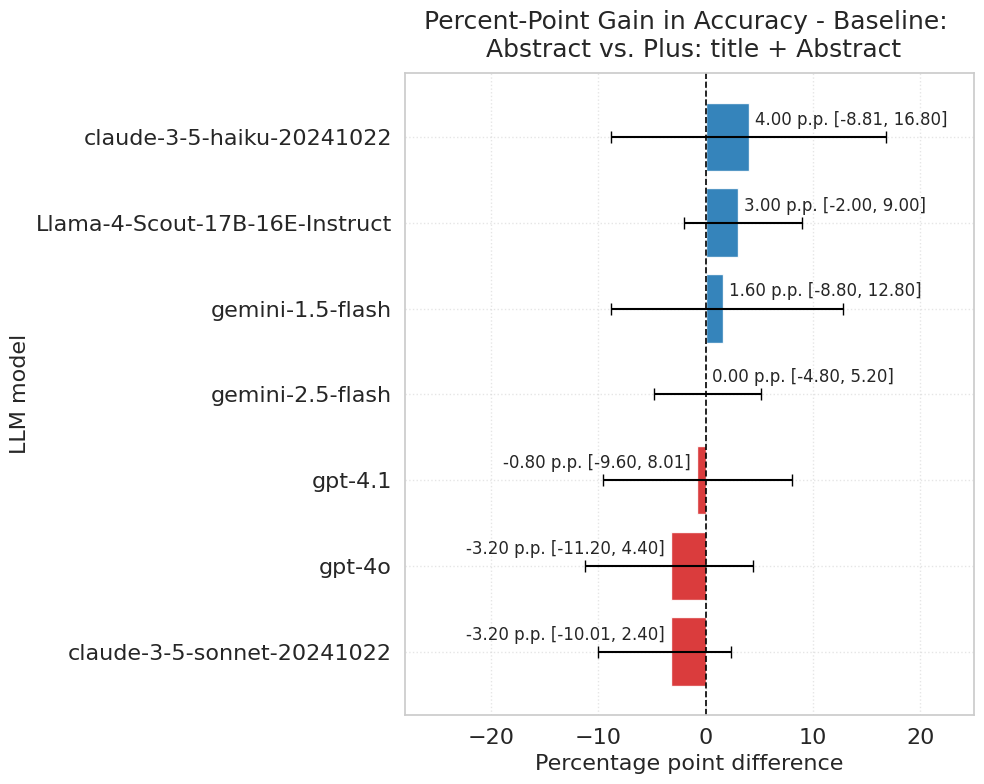

In [51]:
plot_delta_pp_ci(df = df_contr_simple3,
                     model_col="model_id",
                     delta_col="delta_pp",
                     lo_col="ci_low_pp",
                     hi_col="ci_high_pp",
                    title="Percent-Point Gain in Accuracy - Baseline: \n Abstract vs. Plus: title + Abstract",
                     axlabel="Percentage point difference",
                     aylabel="LLM model",
                     figsize=(10,8),
                     xsize=[-28,25],
                     savepath='/data/codigos/dados/resultados/figuras/slr1_2_fase_2_baseline2.png')

In [52]:
df_1 = meta_random_from_ci(df = df_contr_simple3, delta_col="delta_pp", lo_col="ci_low_pp", hi_col="ci_high_pp")
df_1["baseline"] = "abstract"
df_1["contrast"] = "title+abstract"


# guarda
df_meta_ic = pd.concat([df_meta_ic,df_1],ignore_index=True)
df_meta_ic

,k,FE_delta,FE_ci_low,FE_ci_high,RE_delta,RE_ci_low,RE_ci_high,tau2,I2_pct,pred_low,pred_high,baseline,contrast
0,7,0.280371,-1.161255,1.721997,0.280371,-1.161255,1.721997,0.0,0.0,-1.161255,1.721997,abstract,abstract+keywords
1,7,-0.061119,-2.705200,2.582961,-0.061119,-2.705200,2.582961,0.0,0.0,-2.705200,2.582961,abstract,title+abstract


### Abstract vs title+keywords

In [53]:
df_contr_simple4 = delta_takw_vs_ta_bootstrap_from_long(dfl, 
                                                       base="abstract",
                                                       plus="title+keywords",
                                                       B=2000, seed=42, stratify_slr=True)

/tmp/ipykernel_82028/3656458791.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="ID", columns="set_features", values="acc"))
/tmp/ipykernel_82028/3656458791.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="ID", columns="set_features", values="acc"))
/tmp/ipykernel_82028/3656458791.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="ID", columns="set_features", values="acc"))
/tmp/ipykernel_82028/3656458791.py:21: FutureWarning: The def

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Percent-Point Gain in Accuracy - Baseline: \n Abstract vs. Plus: title + Keywords'}, xlabel='Percentage point difference', ylabel='LLM model'>)

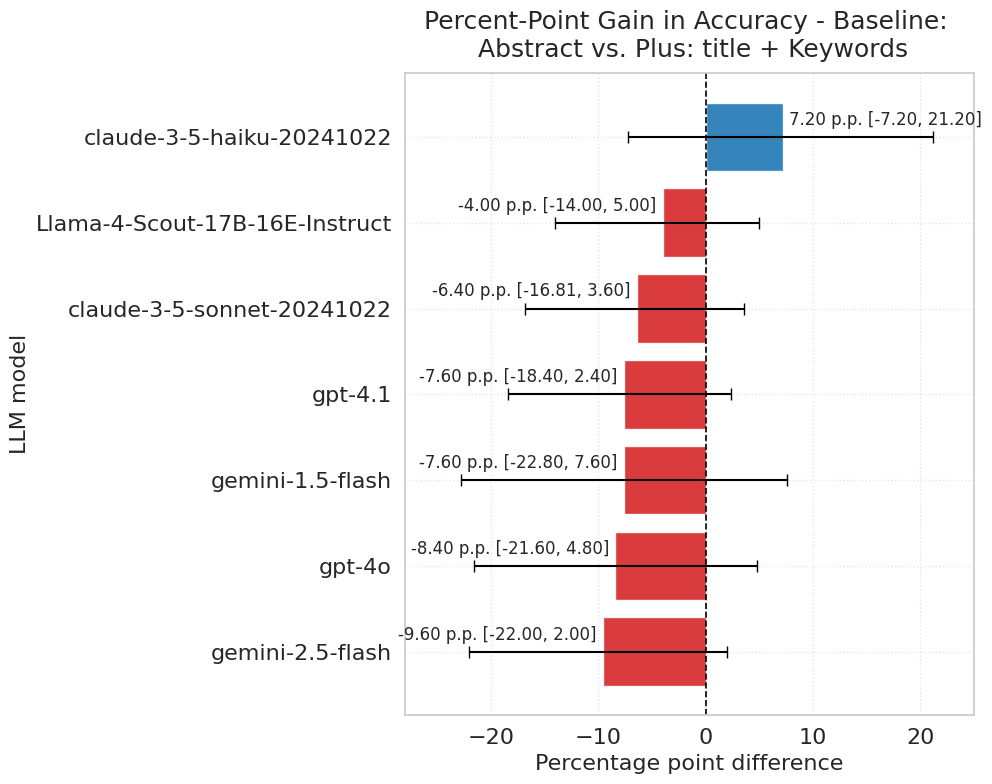

In [54]:
plot_delta_pp_ci(df = df_contr_simple4,
                     model_col="model_id",
                     delta_col="delta_pp",
                     lo_col="ci_low_pp",
                     hi_col="ci_high_pp",
                    title="Percent-Point Gain in Accuracy - Baseline: \n Abstract vs. Plus: title + Keywords",
                     axlabel="Percentage point difference",
                     aylabel="LLM model",
                     figsize=(10,8),
                     xsize=[-28,25],
                     savepath='/data/codigos/dados/resultados/figuras/slr1_2_fase_2_baseline3.png')

In [55]:
df_1 = meta_random_from_ci(df = df_contr_simple4, delta_col="delta_pp", lo_col="ci_low_pp", hi_col="ci_high_pp")
df_1["baseline"] = "abstract"
df_1["contrast"] = "title+keywords"


# guarda
df_meta_ic = pd.concat([df_meta_ic,df_1],ignore_index=True)
df_meta_ic

,k,FE_delta,FE_ci_low,FE_ci_high,RE_delta,RE_ci_low,RE_ci_high,tau2,I2_pct,pred_low,pred_high,baseline,contrast
0,7,0.280371,-1.161255,1.721997,0.280371,-1.161255,1.721997,0.0,0.0,-1.161255,1.721997,abstract,abstract+keywords
1,7,-0.061119,-2.705200,2.582961,-0.061119,-2.705200,2.582961,0.0,0.0,-2.705200,2.582961,abstract,title+abstract
2,7,-5.551233,-9.940771,-1.161695,-5.551233,-9.940771,-1.161695,0.0,0.0,-9.940771,-1.161695,abstract,title+keywords


### abstract vs title+abstract+keywords

In [56]:
df_contr_simple5 = delta_takw_vs_ta_bootstrap_from_long(dfl, 
                                                       base="abstract",
                                                       plus="title+abstract+keywords",
                                                       B=2000, seed=42, stratify_slr=True)

/tmp/ipykernel_82028/3656458791.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="ID", columns="set_features", values="acc"))
/tmp/ipykernel_82028/3656458791.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="ID", columns="set_features", values="acc"))
/tmp/ipykernel_82028/3656458791.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="ID", columns="set_features", values="acc"))
/tmp/ipykernel_82028/3656458791.py:21: FutureWarning: The def

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Percent-Point Gain in Accuracy - Baseline: \n Abstract vs. Plus: Title + Abstract + Keywords'}, xlabel='Percentage point difference', ylabel='LLM model'>)

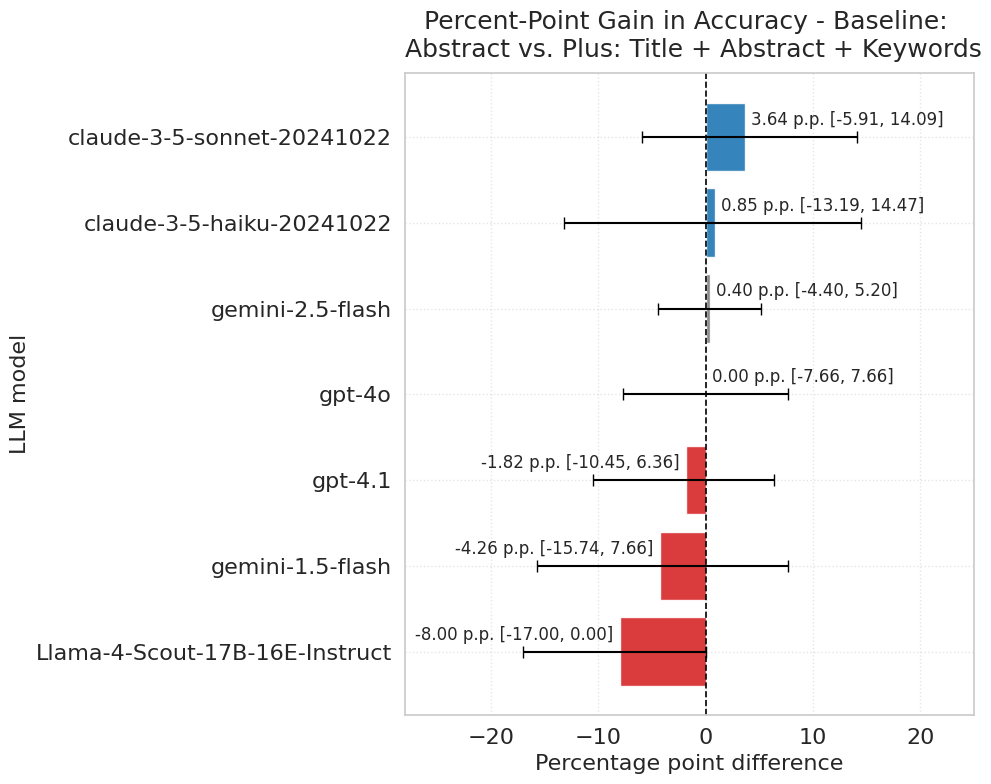

In [57]:
plot_delta_pp_ci(df = df_contr_simple5,
                     model_col="model_id",
                     delta_col="delta_pp",
                     lo_col="ci_low_pp",
                     hi_col="ci_high_pp",
                    title="Percent-Point Gain in Accuracy - Baseline: \n Abstract vs. Plus: Title + Abstract + Keywords",
                     axlabel="Percentage point difference",
                     aylabel="LLM model",
                     figsize=(10,8),
                     xsize=[-28,25],
                     savepath='/data/codigos/dados/resultados/figuras/slr1_2_fase_2_baseline4.png')

In [58]:
df_1 = meta_random_from_ci(df = df_contr_simple5, delta_col="delta_pp", lo_col="ci_low_pp", hi_col="ci_high_pp")
df_1["baseline"] = "abstract"
df_1["contrast"] = "title+abstract+keywords"


# guarda
df_meta_ic = pd.concat([df_meta_ic,df_1],ignore_index=True)
df_meta_ic

,k,FE_delta,FE_ci_low,FE_ci_high,RE_delta,RE_ci_low,RE_ci_high,tau2,I2_pct,pred_low,pred_high,baseline,contrast
0,7,0.280371,-1.161255,1.721997,0.280371,-1.161255,1.721997,0.0,0.0,-1.161255,1.721997,abstract,abstract+keywords
1,7,-0.061119,-2.705200,2.582961,-0.061119,-2.705200,2.582961,0.0,0.0,-2.705200,2.582961,abstract,title+abstract
2,7,-5.551233,-9.940771,-1.161695,-5.551233,-9.940771,-1.161695,0.0,0.0,-9.940771,-1.161695,abstract,title+keywords
3,7,-0.985381,-3.987410,2.016649,-0.985381,-3.987410,2.016649,0.0,0.0,-3.987410,2.016649,abstract,title+abstract+keywords


### title+abstract vs title+abstract+keywords


In [59]:
df_contr_simple6 = delta_takw_vs_ta_bootstrap_from_long(dfl, 
                                                       base="title+abstract",
                                                       plus="title+abstract+keywords",
                                                       B=2000, seed=42, stratify_slr=True)

/tmp/ipykernel_82028/3656458791.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="ID", columns="set_features", values="acc"))
/tmp/ipykernel_82028/3656458791.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="ID", columns="set_features", values="acc"))
/tmp/ipykernel_82028/3656458791.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="ID", columns="set_features", values="acc"))
/tmp/ipykernel_82028/3656458791.py:21: FutureWarning: The def

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Percent-Point Gain in Accuracy - Baseline: \n Title + Abstract vs. Plus: Title + Abstract + Keywords'}, xlabel='Percentage point difference', ylabel='LLM model'>)

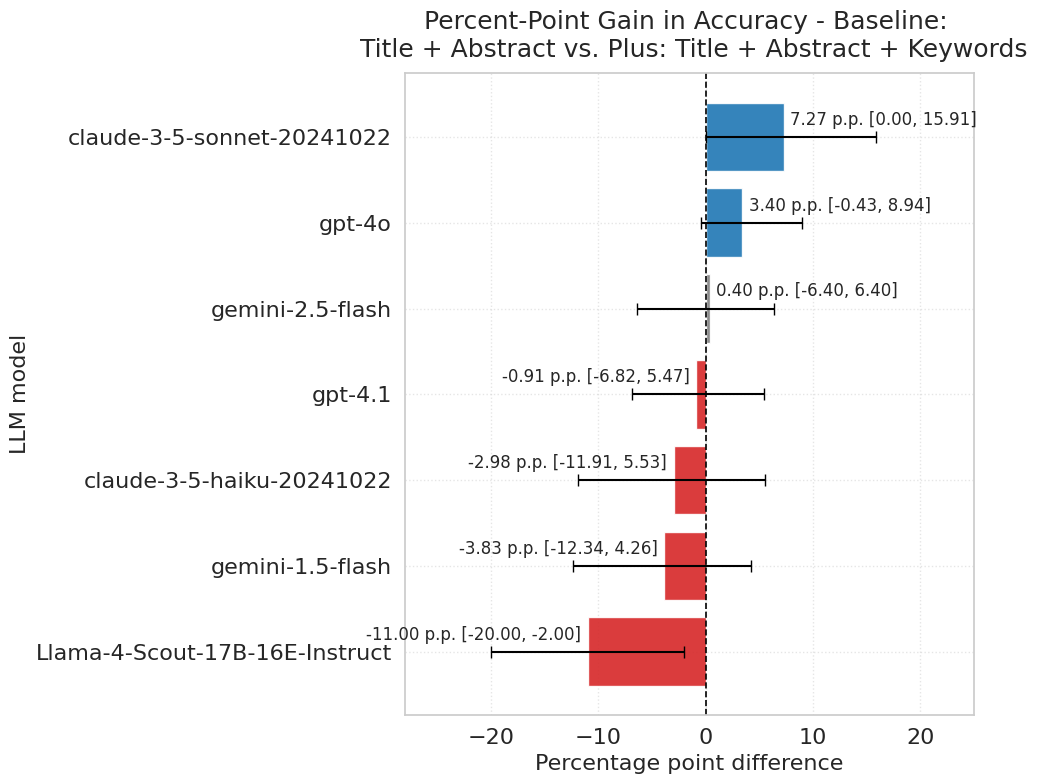

In [60]:
plot_delta_pp_ci(df = df_contr_simple6,
                     model_col="model_id",
                     delta_col="delta_pp",
                     lo_col="ci_low_pp",
                     hi_col="ci_high_pp",
                    title="Percent-Point Gain in Accuracy - Baseline: \n Title + Abstract vs. Plus: Title + Abstract + Keywords",
                     axlabel="Percentage point difference",
                     aylabel="LLM model",
                     figsize=(10,8),
                     xsize=[-28,25],
                     savepath='/data/codigos/dados/resultados/figuras/slr1_2_fase_2_baseline5.png')

In [61]:
df_1 = meta_random_from_ci(df = df_contr_simple6, delta_col="delta_pp", lo_col="ci_low_pp", hi_col="ci_high_pp")
df_1["baseline"] = "title+abstract"
df_1["contrast"] = "title+abstract+keywords"


# guarda
df_meta_ic = pd.concat([df_meta_ic,df_1],ignore_index=True)
df_meta_ic

,k,FE_delta,FE_ci_low,FE_ci_high,RE_delta,RE_ci_low,RE_ci_high,tau2,I2_pct,pred_low,pred_high,baseline,contrast
0,7,0.280371,-1.161255,1.721997,0.280371,-1.161255,1.721997,0.000000,0.000000,-1.161255,1.721997,abstract,abstract+keywords
1,7,-0.061119,-2.705200,2.582961,-0.061119,-2.705200,2.582961,0.000000,0.000000,-2.705200,2.582961,abstract,title+abstract
2,7,-5.551233,-9.940771,-1.161695,-5.551233,-9.940771,-1.161695,0.000000,0.000000,-9.940771,-1.161695,abstract,title+keywords
3,7,-0.985381,-3.987410,2.016649,-0.985381,-3.987410,2.016649,0.000000,0.000000,-3.987410,2.016649,abstract,title+abstract+keywords
4,7,0.166766,-2.395010,2.728541,-0.499162,-4.315708,3.317385,13.181358,51.342169,-8.574032,7.575709,title+abstract,title+abstract+keywords


In [62]:
print(df_meta_ic)

   k  FE_delta  FE_ci_low  FE_ci_high  RE_delta  RE_ci_low  RE_ci_high  \
0  7  0.280371  -1.161255    1.721997  0.280371  -1.161255    1.721997   
1  7 -0.061119  -2.705200    2.582961 -0.061119  -2.705200    2.582961   
2  7 -5.551233  -9.940771   -1.161695 -5.551233  -9.940771   -1.161695   
3  7 -0.985381  -3.987410    2.016649 -0.985381  -3.987410    2.016649   
4  7  0.166766  -2.395010    2.728541 -0.499162  -4.315708    3.317385   

        tau2     I2_pct  pred_low  pred_high        baseline  \
0   0.000000   0.000000 -1.161255   1.721997        abstract   
1   0.000000   0.000000 -2.705200   2.582961        abstract   
2   0.000000   0.000000 -9.940771  -1.161695        abstract   
3   0.000000   0.000000 -3.987410   2.016649        abstract   
4  13.181358  51.342169 -8.574032   7.575709  title+abstract   

                  contrast  
0        abstract+keywords  
1           title+abstract  
2           title+keywords  
3  title+abstract+keywords  
4  title+abstract+keyword


Realizamos meta-análises por contraste, tratando cada modelo como um ‘estudo’. A variância intra-modelo foi derivada dos IC95% obtidos via bootstrap por artigo; agregamos os efeitos com o modelo de **efeitos aleatórios de DerSimonian–Laird** (além do estimador de **efeitos fixos**), reportando **I²** e **intervalos de predição**. Assim, sintetizamos o **ganho médio** e a **heterogeneidade entre modelos** de forma transparente.


In [ ]:

def plot_meta_forest(df_meta,
                     effect_col="RE_delta",
                     ci_low_col="RE_ci_low",
                     ci_high_col="RE_ci_high",
                     pred_low_col="pred_low",
                     pred_high_col="pred_high",
                     label_cols=("baseline","contrast"),
                     sesoi_pp=None,    # ex.: 2.0 para faixa ±2 p.p.
                     title="Meta-análise por contraste (efeitos aleatórios)",
                     figsize=None,
                     savepath=None):
    """
    df_meta: tabela como a sua (uma linha por 'baseline × contrast').
    """

    df = df_meta.copy()
    df["label"] = df[label_cols[1]]  # contrast
    df = df.sort_values([label_cols[0], effect_col]).reset_index(drop=True)

    # status (para cor)
    def status(row):
        lo, hi = row[ci_low_col], row[ci_high_col]
        if hi < 0:  return "↓ inferior"
        if lo > 0:  return "↑ superior"
        return "≈ inconclusivo"
    df["status"] = df.apply(status, axis=1)

    baselines = df[label_cols[0]].unique().tolist()
    n_panels = len(baselines)

    # alturas proporcionais ao nº de linhas por baseline
    height_ratios = [df[df[label_cols[0]] == b].shape[0] for b in baselines]

    if figsize is None:
        figsize = (10, max(3, 2.2 * n_panels + 1))

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(
        n_panels, 1,
        figsize=figsize, sharex=True,
        gridspec_kw={"height_ratios": height_ratios}
    )
    if n_panels == 1:
        axes = [axes]

    palette = {"↑ superior":"#2ca02c", "↓ inferior":"#d62728", "≈ inconclusivo":"#7f7f7f"}

    # Vamos preparar handles para a legenda global
    global_handles = []
    global_labels = []

    # calcular range global para set_xlim com margem (evita texto fora)
    xmin = np.nanmin(df[ci_low_col].values)
    xmax = np.nanmax(df[ci_high_col].values)
    xrng = xmax - xmin if xmax > xmin else 1.0
    pad = 0.08 * xrng  # 8% de margem de cada lado
    xleft, xright = xmin - pad, xmax + pad

    for ax, base in zip(axes, baselines):
        sub = df[df[label_cols[0]] == base].copy().reset_index(drop=True)
        y = np.arange(len(sub))

        # faixa SESOI (opcional)
        if sesoi_pp is not None:
            p = ax.axvspan(-sesoi_pp, sesoi_pp, color="#c5c5c5", alpha=0.2, label="SESOI")
            global_handles.append(p); global_labels.append("SESOI")

        # IC95% (linha)
        l_ic = ax.hlines(y, sub[ci_low_col], sub[ci_high_col],
                         color="#1f77b4", lw=5, alpha=0.9, label="IC95% (RE)")
        global_handles.append(l_ic); global_labels.append("IC95% (RE)")

        # ponto pooled
        colors = [palette[s] for s in sub["status"]]
        sc = ax.scatter(sub[effect_col], y, s=90, color=colors, edgecolor="black", zorder=5, label="Pooled (RE)")
        global_handles.append(sc); global_labels.append("Pooled (RE)")

        # anotações (garantir que fiquem dentro do eixo)
        dx = 0.02 * (xright - xleft)  # deslocamento horizontal
        for i, r in sub.iterrows():
            x = float(r[effect_col])
            lo = float(r[ci_low_col]); hi = float(r[ci_high_col])
            txt = f"{x:.2f} p.p. [{lo:.2f}, {hi:.2f}]"

            # posição do texto: desloca para dentro conforme o sinal
            if x >= 0:
                x_text = min(x + dx, xright - 0.5 * xrng)
                ha = "left"
            else:
                x_text = max(x - dx, xleft + 0.7 * xrng)
                ha = "right"

            ax.text(x, i, txt, fontsize=11, ha=ha, va="bottom", clip_on=True)

        # estética
        ax.set_xlim(xleft, xright)
        ax.axvline(0, color="black", ls="--", lw=1)
        ax.set_yticks(y)
        ax.set_yticklabels(sub["label"])
        ax.set_title(f"baseline = {base}", loc="left", fontsize=14)
        ax.grid(axis="y", linestyle=":", alpha=0.4)
        ax.grid(axis="x", linestyle=":", alpha=0.4)

    # Eixo x e títulos
    axes[-1].set_xlabel("Diferença em pontos percentuais (contrast − baseline)")
    fig.suptitle(title, y=0.995, fontsize=16)

    # Legenda global no rodapé (remove duplicatas preservando ordem)
    seen = set()
    handles_unique, labels_unique = [], []
    for h, l in zip(global_handles, global_labels):
        if l not in seen:
            handles_unique.append(h)
            labels_unique.append(l)
            seen.add(l)
    fig.legend(handles_unique, labels_unique,
               loc="lower center", ncol=len(labels_unique),
               frameon=False, fontsize=10, bbox_to_anchor=(0.5, -0.02))

    # Ajustes de layout para caber legenda global
    plt.tight_layout(rect=[0, 0.05, 1, 0.97])  # deixa espaço embaixo e no topo

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
    return fig, axes


In [71]:

def plot_meta_forest(df_meta,
                     effect_col="RE_delta",
                     ci_low_col="RE_ci_low",
                     ci_high_col="RE_ci_high",
                     pred_low_col="pred_low",
                     pred_high_col="pred_high",
                     label_cols=("baseline","contrast"),
                     sesoi_pp=None,    # ex.: 2.0 para faixa ±2 p.p.
                     title="Meta-análise por contraste (efeitos aleatórios)",
                     figsize=None,
                     savepath=None):
    """
    df_meta: tabela como a sua (uma linha por 'baseline × contrast').
    """

    df = df_meta.copy()
    df["label"] = df[label_cols[1]]  # contrast
    df = df.sort_values([label_cols[0], effect_col]).reset_index(drop=True)

    # status (para cor)
    def status(row):
        lo, hi = row[ci_low_col], row[ci_high_col]
        if hi < 0:  return "↓ inferior"
        if lo > 0:  return "↑ superior"
        return "≈ inconclusivo"
    df["status"] = df.apply(status, axis=1)

    baselines = df[label_cols[0]].unique().tolist()
    n_panels = len(baselines)

    # alturas proporcionais ao nº de linhas por baseline
    height_ratios = [df[df[label_cols[0]] == b].shape[0] for b in baselines]
    if height_ratios:
        # dá um gás extra no primeiro painel para anotações não cortarem no topo
        height_ratios[0] = int(height_ratios[0] * 1.25 + 1)

    if figsize is None:
        figsize = (10, max(3, 2.2 * n_panels + 1))

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(
        n_panels, 1,
        figsize=figsize, sharex=True,
        gridspec_kw={"height_ratios": height_ratios}
    )
    if n_panels == 1:
        axes = [axes]

    palette = {"↑ superior":"#2ca02c", "↓ inferior":"#d62728", "≈ inconclusivo":"#7f7f7f"}

    # handles para legenda global
    global_handles, global_labels = [], []

    # range global do eixo x com margem
    xmin = np.nanmin(df[ci_low_col].values)
    xmax = np.nanmax(df[ci_high_col].values)
    xrng = xmax - xmin if xmax > xmin else 1.0
    pad = 0.08 * xrng  # 8% de margem
    xleft, xright = xmin - pad, xmax + pad

    for ax, base in zip(axes, baselines):
        sub = df[df[label_cols[0]] == base].copy().reset_index(drop=True)
        y = np.arange(len(sub))

        # faixa SESOI (opcional)
        if sesoi_pp is not None:
            p = ax.axvspan(-sesoi_pp, sesoi_pp, color="#c5c5c5", alpha=0.2, label="SESOI")
            global_handles.append(p); global_labels.append("SESOI")

        # IC95% (linha)
        l_ic = ax.hlines(y, sub[ci_low_col], sub[ci_high_col],
                         color="#1f77b4", lw=5, alpha=0.9, label="IC95% (RE)")
        global_handles.append(l_ic); global_labels.append("IC95% (RE)")

        # ponto pooled
        colors = [palette[s] for s in sub["status"]]
        sc = ax.scatter(sub[effect_col], y, s=90, color=colors, edgecolor="black", zorder=5, label="Pooled (RE)")
        global_handles.append(sc); global_labels.append("Pooled (RE)")

        # anotações — agora usando x_text e com deslocamento vertical
        dx = 0.02 * (xright - xleft)   # deslocamento horizontal
        dy = 0.18                      # leve deslocamento vertical
        for i, r in sub.iterrows():
            x = float(r[effect_col])
            lo = float(r[ci_low_col]); hi = float(r[ci_high_col])
            txt = f"{x:.2f} p.p. [{lo:.2f}, {hi:.2f}]"

            if x >= 0:
                x_text = min(x + dx, xright - 0.01 * xrng)
                ha = "left"
            else:
                x_text = max(x - dx, xleft + 0.01 * xrng)
                ha = "right"

            ax.text(x, i + dy, txt, fontsize=11, ha="center", va="center", clip_on=False)

        # estética
        ax.set_xlim(xleft, xright)
        # padding vertical para sobrar “teto”
        ypad = 0.6
        ax.set_ylim(-0.5, len(sub) - 0.5 + ypad)

        ax.axvline(0, color="black", ls="--", lw=1)
        ax.set_yticks(y)
        ax.tick_params(axis='both', labelsize=14)
        ax.set_yticklabels(sub["label"])
        ax.set_title(f"baseline:  {base}", loc="left", fontsize=16)
        ax.grid(axis="y", linestyle=":", alpha=0.4)
        ax.grid(axis="x", linestyle=":", alpha=0.4)

    # Eixo x e títulos
    axes[-1].set_xlabel("Percentage point difference (contrast-baseline)")
    fig.suptitle(title, y=0.97, fontsize=16)  # um pouco mais baixo para não colar no topo

    # Legenda global no rodapé (sem duplicatas)
    seen = set(); handles_unique = []; labels_unique = []
    for h, l in zip(global_handles, global_labels):
        if l not in seen:
            handles_unique.append(h); labels_unique.append(l); seen.add(l)
    fig.legend(handles_unique, labels_unique,
               loc="lower center", ncol=len(labels_unique),
               frameon=False, fontsize=10, bbox_to_anchor=(0.5, -0.02))

    # layout com mais respiro no topo e rodapé (para legenda)
    plt.tight_layout(rect=[0, 0.06, 1, 0.94])

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
    return fig, axes


(<Figure size 900x600 with 2 Axes>,
 array([<Axes: title={'left': 'baseline:  abstract'}>,
        <Axes: title={'left': 'baseline:  title+abstract'}, xlabel='Percentage point difference (contrast-baseline)'>],
       dtype=object))

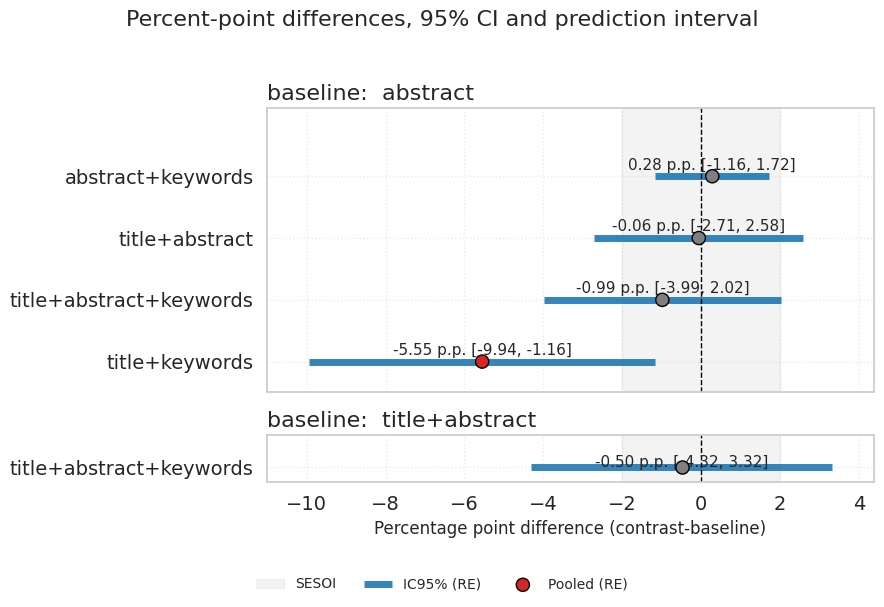

In [73]:
plot_meta_forest(df_meta = df_meta_ic,
                     effect_col="RE_delta",
                     ci_low_col="RE_ci_low",
                     ci_high_col="RE_ci_high",
                     pred_low_col="pred_low",
                     pred_high_col="pred_high",
                     label_cols=("baseline","contrast"),
                     sesoi_pp=2.0,    # ex.: 2.0 para faixa ±2 p.p.
                     title="Percent-point differences, 95% CI and prediction interval",
                     figsize=(9,6),
                     savepath='/data/codigos/dados/resultados/figuras/slr1_2_fase_2_meta_analysis.png')